# Evaluating a trained KIND model on ETTh2 dataset

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

### Load a trained KIND model

In [2]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/et_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=144, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=6, out_features=6, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=432, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_me

### Analyze the stationary part of a KIND model

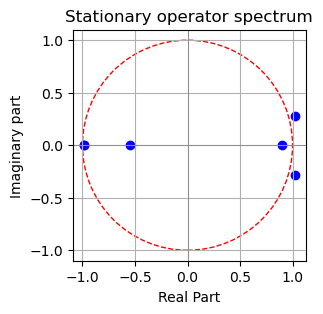

tensor([ 1.0230+0.2789j,  1.0230-0.2789j,  0.8955+0.0000j, -0.5498+0.0000j,
        -0.9879+0.0000j, -0.9895+0.0000j])


In [3]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

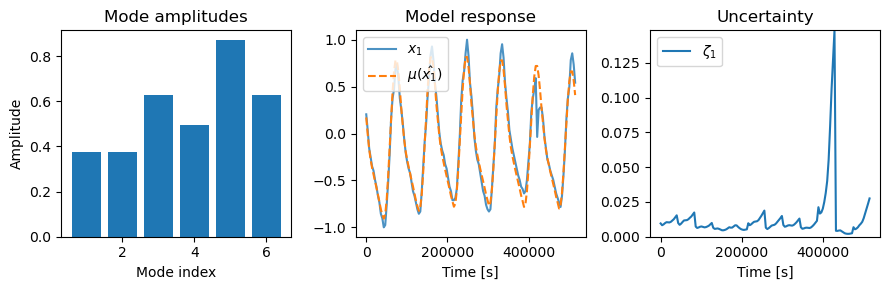

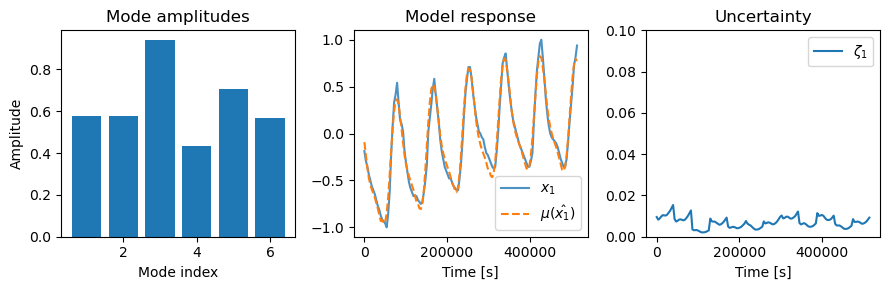

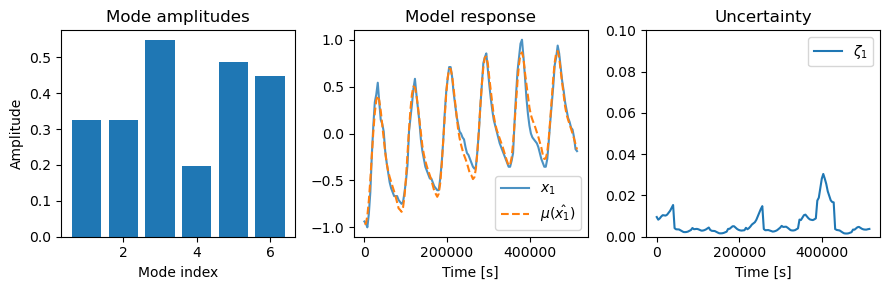

In [4]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/et_train_stat'
timeseries_nsample = 144

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Evaluate KIND performance on test data

In [5]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/et_test'
timeseries_nsample = 8875

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend        737      0.006
 worst blend       2251      2.203
   avg blend         na      0.178
                                  
   best stat       8532      0.004
  worst stat       3531      3.192
    avg stat         na      0.331
                                  
  best trans       6217      0.007
 worst trans       2249      2.544
   avg trans         na      0.190

inf >> mean alpha is 0.13



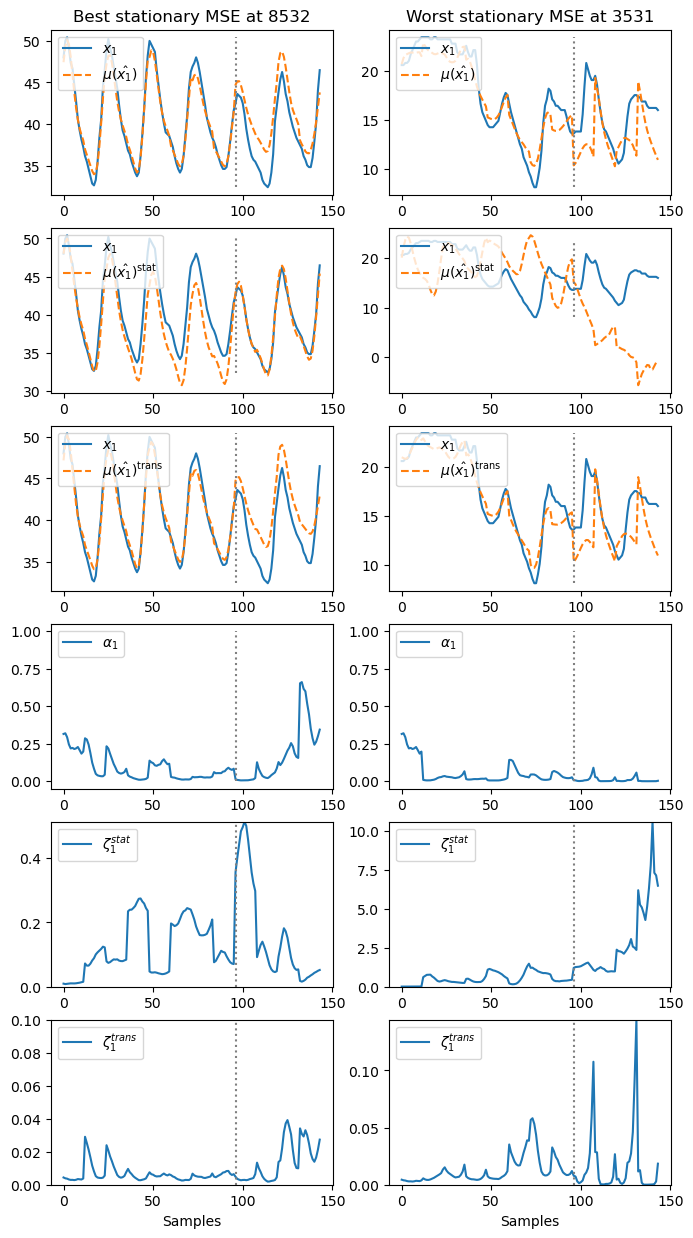

In [6]:
# --! plot the best and worst stationary performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_stat, mse_type='stationary',
    datasaved=True, savedir='../../savedata/baselines/et')

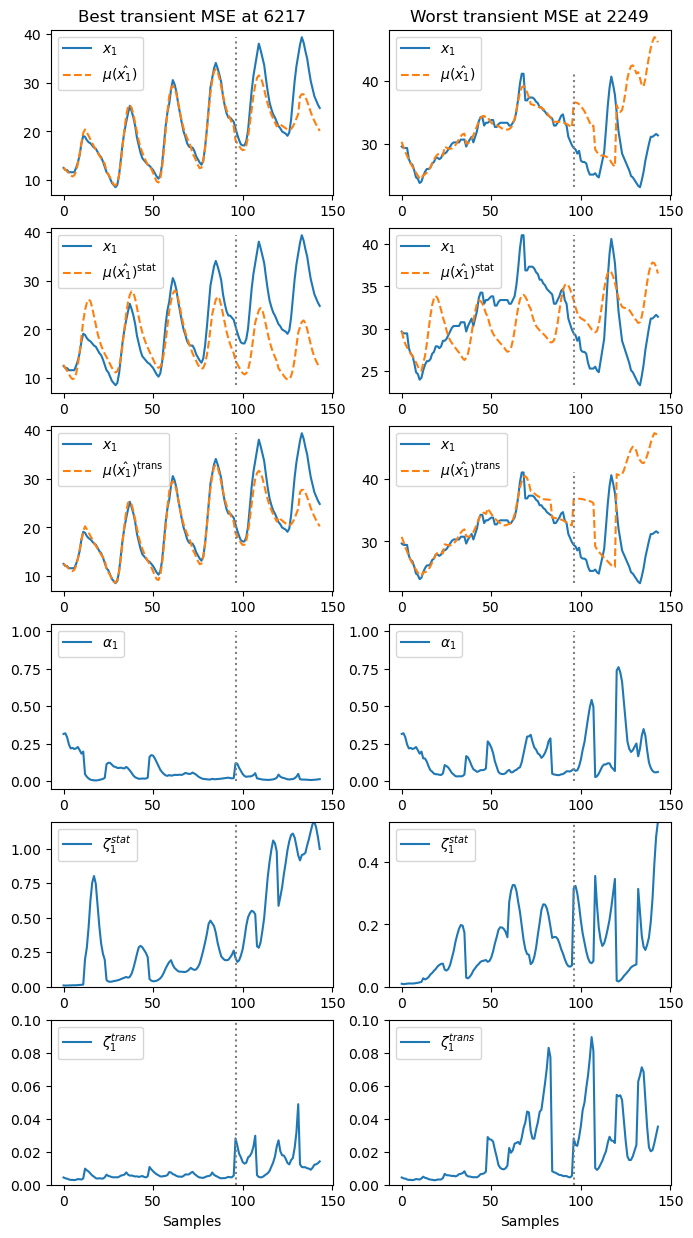

In [7]:
# --! plot the best and worst transient performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_trans, mse_type='transient',
    datasaved=True, savedir='../../savedata/baselines/et')

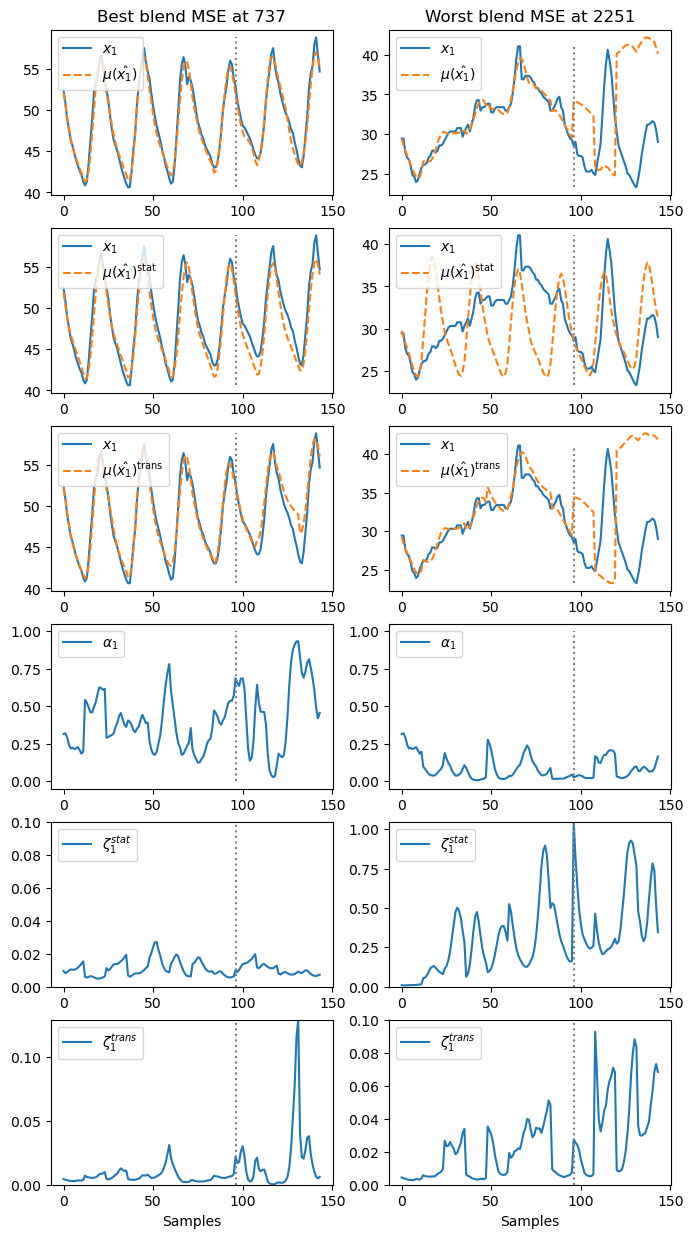

In [8]:
# --! plot the best and worst blending performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    datasaved=True, savedir='../../savedata/baselines/et')

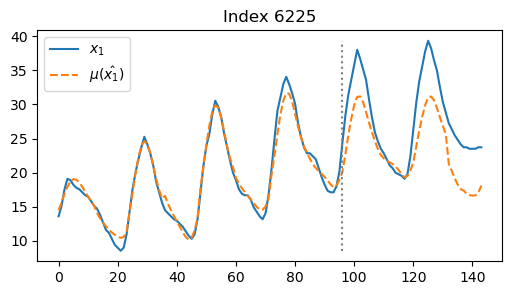

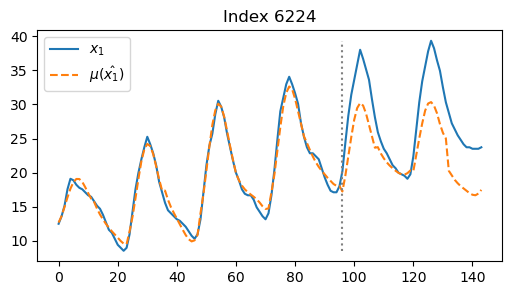

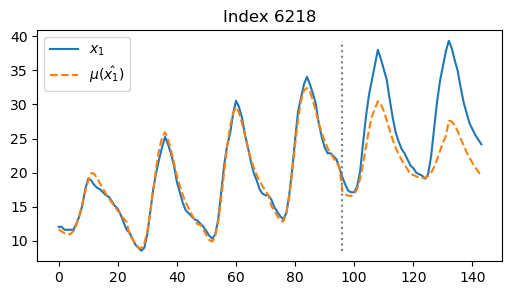

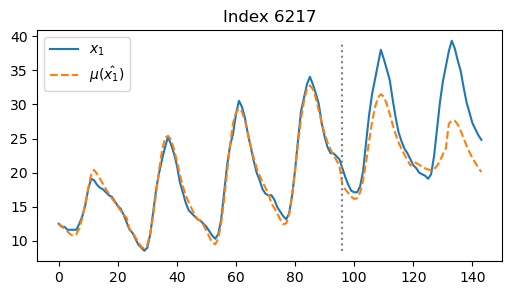

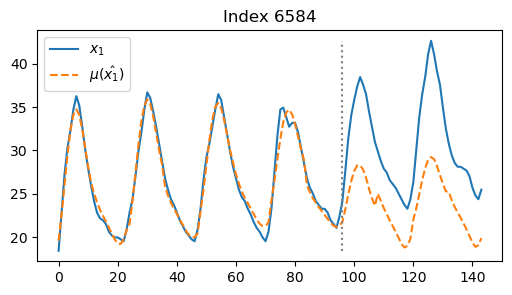

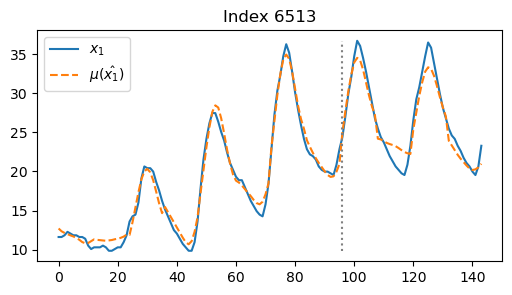

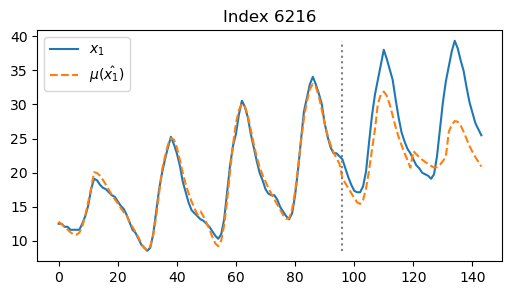

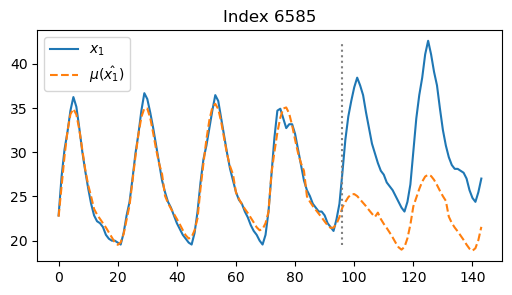

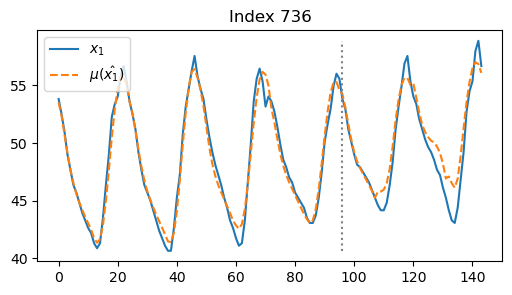

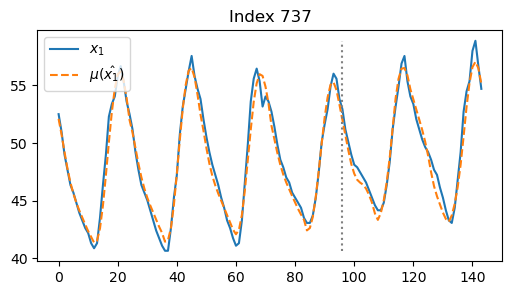

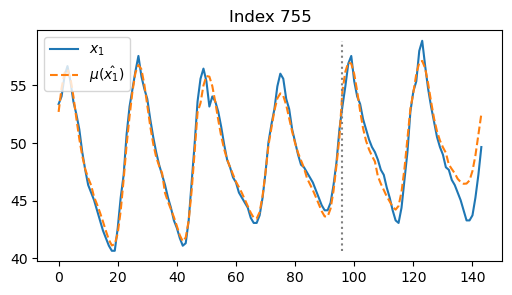

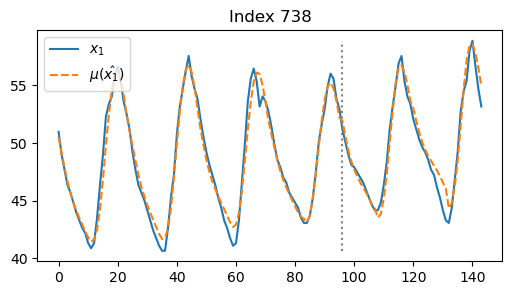

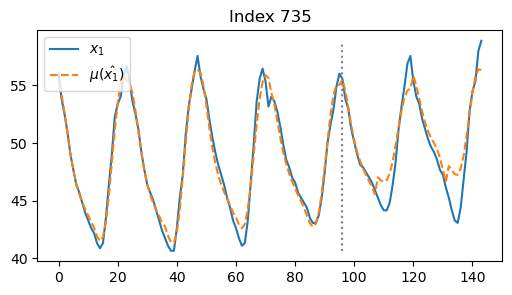

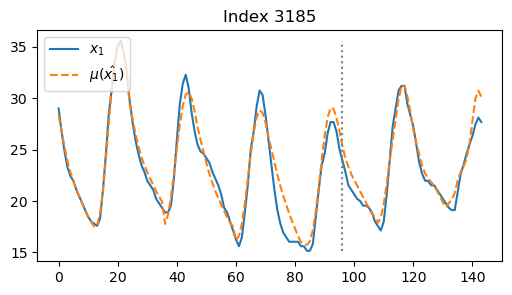

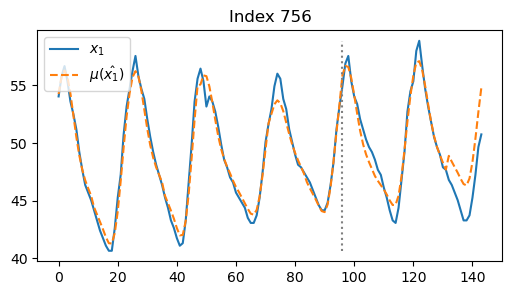

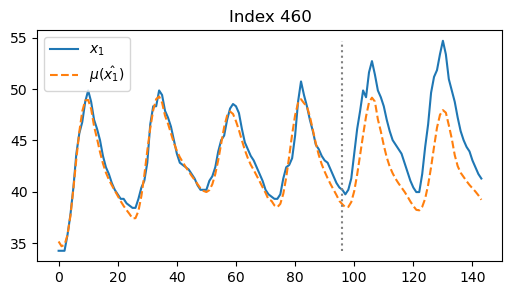

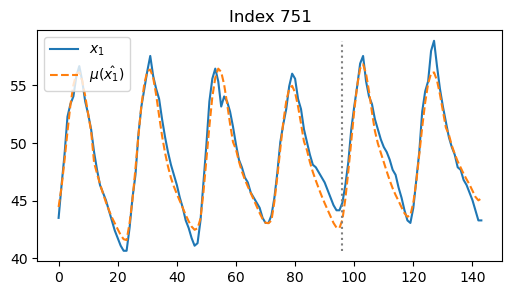

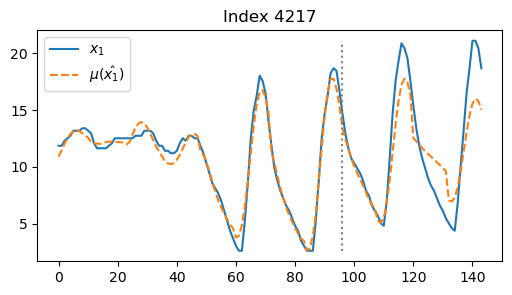

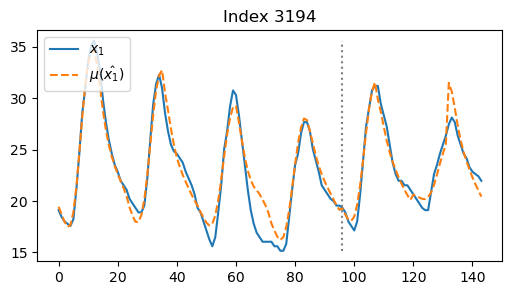

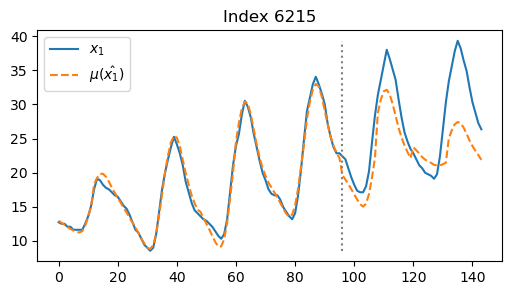

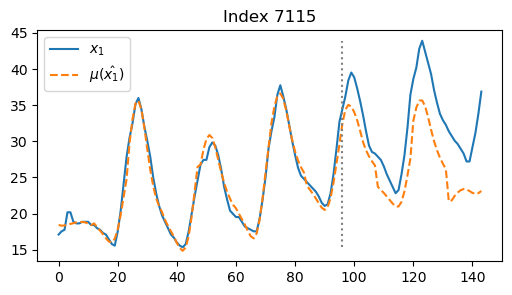

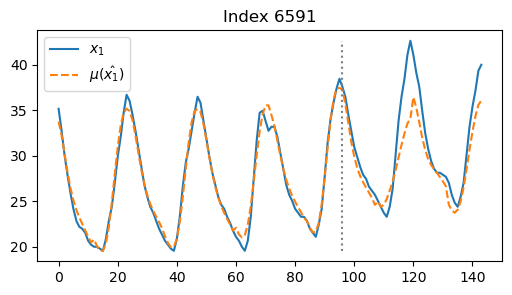

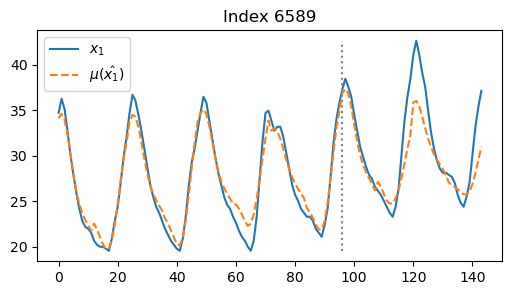

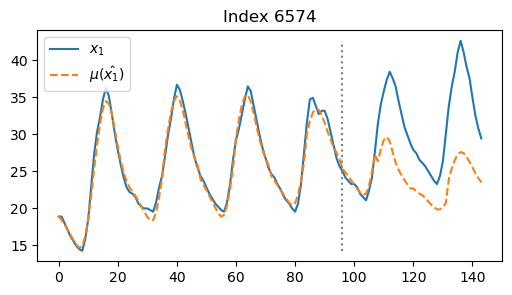

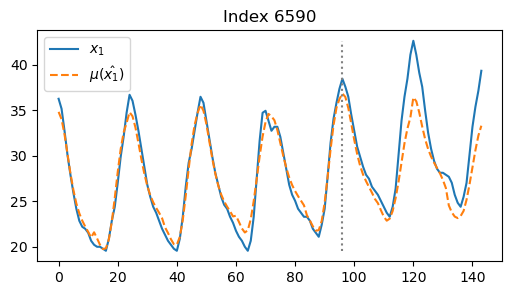

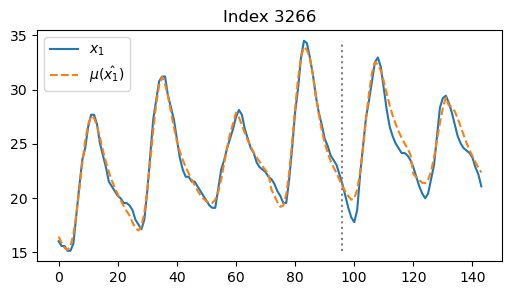

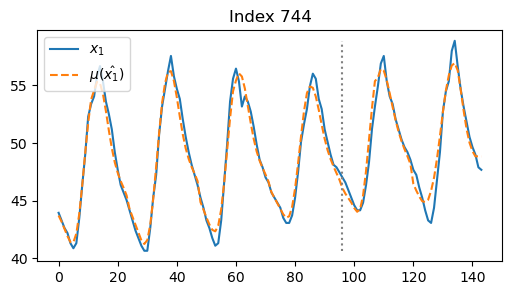

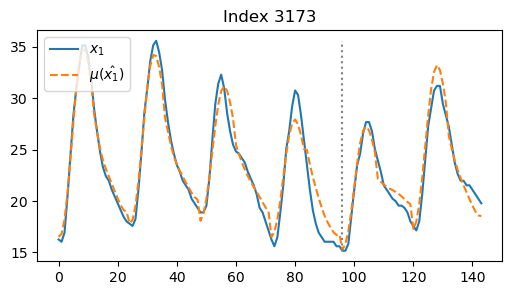

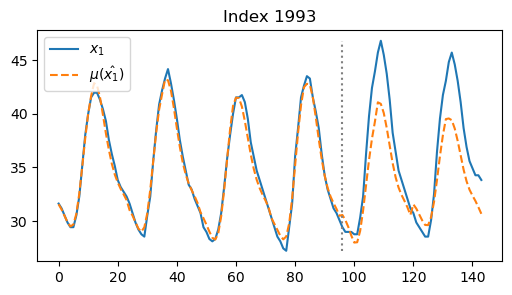

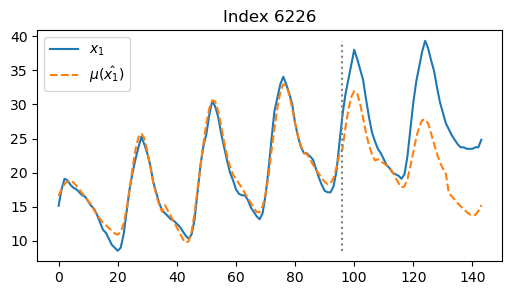

In [13]:
utils_plot.plot_mse_extreme2(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    k=30,
    jsave=6513,
    datasaved=False, savedir='../../savedata/baselines/et')